# 7. Programación Orientada a Objetos (OOP) en Python

## Objetivos

1. Comprender los conceptos fundamentales de OOP: clases, objetos, atributos y métodos.
2. Implementar encapsulamiento, herencia, polimorfismo y abstracción.
3. Dominar los métodos especiales (*dunder*) para crear objetos expresivos.
4. Organizar el código en módulos y paquetes.
5. Aplicar patrones de diseño: Singleton, Factory, Strategy y Observer.
6. Modelar sistemas físicos con OOP.

---

## Mapa conceptual

```
OOP
├── 1. Conceptos básicos       → clase, objeto, atributo, método, self
├── 2. Métodos especiales      → __init__, __str__, __add__, __len__, ...
├── 3. Encapsulamiento         → público, _protegido, __privado, @property
├── 4. Herencia & Polimorfismo → super(), ABC, @abstractmethod
├── 5. Patrones de diseño      → Singleton, Factory, Strategy, Observer
├── 6. Módulos y paquetes      → import, __init__.py
└── 7. Buenas prácticas        → SOLID, composición, docstrings
```

> **Filosofía clave:** en OOP modelamos el mundo como *objetos* que tienen *estado* (atributos) y *comportamiento* (métodos).

---
## 1. Conceptos básicos: clase, objeto, atributo y método

### ¿Por qué OOP?

Sin OOP, datos y funciones están desconectados. Es difícil agrupar lógica relacionada, validar datos o reutilizar código de forma segura.

In [1]:
# Sin OOP: datos y funciones desconectadas
v1 = [1, 2, 3]
v2 = [4, 5, 6]

def sumar_vectores(a, b):
    return [a[i] + b[i] for i in range(len(a))]

def magnitud(v):
    return sum(x**2 for x in v) ** 0.5

print('Suma:      ', sumar_vectores(v1, v2))
print('Magnitud v1:', round(magnitud(v1), 4))
# Problema: nada impide pasar datos invalidos; sin estructura clara

Suma:       [5, 7, 9]
Magnitud v1: 3.7417


Con OOP **encapsulamos** datos y comportamiento en una sola unidad: la **clase**.

### Anatomía de una clase

```python
class NombreClase:           # 1. Definicion (CamelCase)
    'Docstring.'             # 2. Documentacion

    def __init__(self, ...): # 3. Constructor
        self.atributo = ...  # 4. Atributos de instancia

    def metodo(self):        # 5. Metodos
        ...
```

| Término | Significado |
|---------|-------------|
| **Clase** | Plantilla / molde |
| **Objeto / Instancia** | Ejemplar concreto creado desde la clase |
| **Atributo** | Variable que pertenece a un objeto |
| **Método** | Función definida dentro de la clase |
| **`self`** | Referencia al objeto actual; siempre primer parámetro |

### Ejemplo 1 — Clase `Vector` desde cero

In [2]:
class Vector:
    """Representa un vector en 2D o 3D."""

    def __init__(self, x, y, z=0):
        """Inicializa el vector con sus componentes."""
        self.x = x
        self.y = y
        self.z = z

    def sumar(self, otro):
        """Devuelve la suma componente a componente."""
        return Vector(self.x + otro.x, self.y + otro.y, self.z + otro.z)

    def magnitud(self):
        """Modulo del vector."""
        return (self.x**2 + self.y**2 + self.z**2) ** 0.5

    def __str__(self):
        """print(v) llama este metodo."""
        return f"Vector({self.x}, {self.y}, {self.z})"


v1 = Vector(1, 2, 3)
v2 = Vector(4, 5, 6)

print("v1:", v1)
print("v2:", v2)
print("Suma:", v1.sumar(v2))
print("|v1|:", round(v1.magnitud(), 4))
print("Tipo:", type(v1))

v1: Vector(1, 2, 3)
v2: Vector(4, 5, 6)
Suma: Vector(5, 7, 9)
|v1|: 3.7417
Tipo: <class '__main__.Vector'>


### `self` — la referencia al objeto actual

`self` es quien llama al método. Python lo pasa automáticamente:

```python
v1.sumar(v2)   # Python traduce esto a: Vector.sumar(v1, v2)
```

### Atributos de clase vs. atributos de instancia

| | Atributo de clase | Atributo de instancia |
|-|-------------------|-----------------------|
| **Definición** | Fuera de `__init__` | Dentro de `__init__` con `self` |
| **Compartido** | Por todos los objetos | Único por cada objeto |
| **Uso típico** | Contadores, constantes | Estado del objeto |

In [3]:
class Particula:
    """Particula con contador global de instancias."""

    contador = 0          # atributo de CLASE (compartido)

    def __init__(self, nombre, masa, carga):
        self.nombre = nombre  # atributos de INSTANCIA (unicos)
        self.masa   = masa
        self.carga  = carga
        Particula.contador += 1

    def energia_reposo(self):
        """E = mc^2"""
        return self.masa * (3e8)**2

    def __str__(self):
        return f"{self.nombre}(m={self.masa:.2e} kg, q={self.carga:+.2e} C)"


e = Particula("Electron", 9.109e-31, -1.602e-19)
p = Particula("Proton",   1.673e-27, +1.602e-19)

print(e)
print(p)
print(f"Particulas creadas: {Particula.contador}")
print(f"E reposo electron: {e.energia_reposo():.3e} J")

Electron(m=9.11e-31 kg, q=-1.60e-19 C)
Proton(m=1.67e-27 kg, q=+1.60e-19 C)
Particulas creadas: 2
E reposo electron: 8.198e-14 J


---
## 2. Métodos especiales (*dunder*) y sobrecarga de operadores

Permiten que tus objetos se comporten como tipos nativos de Python.

### Tabla de métodos especiales más usados

| Método | Se activa cuando... |
|--------|---------------------|
| `__init__` | Se crea el objeto |
| `__str__` | `print(obj)` o `str(obj)` |
| `__repr__` | `repr(obj)` o en el intérprete |
| `__len__` | `len(obj)` |
| `__add__` | `obj + otro` |
| `__sub__` | `obj - otro` |
| `__mul__` | `obj * escalar` |
| `__rmul__` | `escalar * obj` (orden inverso) |
| `__truediv__` | `obj / otro` |
| `__eq__` | `obj == otro` |
| `__abs__` | `abs(obj)` |
| `__getitem__` | `obj[i]` |
| `__iter__` | `for x in obj` |
| `__contains__` | `x in obj` |

> **`__str__` vs `__repr__`:** `__str__` es para el usuario; `__repr__` es para el desarrollador (reproducible). Si solo defines uno, define `__repr__`.

### Ejemplo 2 — `Vector` con operadores completos

In [4]:
import math

class Vector:
    """Vector 2D/3D con operadores aritmeticos completos."""

    def __init__(self, x, y, z=0):
        self.x, self.y, self.z = x, y, z

    # Representacion
    def __str__(self):   return f"({self.x}, {self.y}, {self.z})"
    def __repr__(self):  return f"Vector({self.x!r}, {self.y!r}, {self.z!r})"

    # Aritmetica
    def __add__(self, o):  return Vector(self.x+o.x, self.y+o.y, self.z+o.z)
    def __sub__(self, o):  return Vector(self.x-o.x, self.y-o.y, self.z-o.z)
    def __neg__(self):     return Vector(-self.x, -self.y, -self.z)
    def __mul__(self, k):  return Vector(self.x*k, self.y*k, self.z*k)
    def __rmul__(self, k): return self.__mul__(k)   # conmutatividad: 3*v
    def __truediv__(self, k):
        if k == 0: raise ZeroDivisionError("No se puede dividir por cero.")
        return Vector(self.x/k, self.y/k, self.z/k)

    # Comparacion y magnitud
    def __eq__(self, o):
        return (math.isclose(self.x,o.x) and
                math.isclose(self.y,o.y) and
                math.isclose(self.z,o.z))
    def __abs__(self):   return math.sqrt(self.x**2+self.y**2+self.z**2)
    def __len__(self):   return 2 if self.z == 0 else 3

    # Metodos geometricos
    def producto_punto(self, o):
        return self.x*o.x + self.y*o.y + self.z*o.z

    def producto_cruz(self, o):
        return Vector(self.y*o.z-self.z*o.y,
                      self.z*o.x-self.x*o.z,
                      self.x*o.y-self.y*o.x)

    def normalizar(self):
        mag = abs(self)
        if mag == 0: raise ValueError("Vector cero no tiene direccion.")
        return self / mag


v1 = Vector(1, 2, 3)
v2 = Vector(4, 5, 6)

print("v1 + v2 =", v1 + v2)
print("v1 - v2 =", v1 - v2)
print("v1 * 3  =", v1 * 3)
print("3 * v1  =", 3 * v1)           # usa __rmul__
print("-v1     =", -v1)
print("|v1|    =", round(abs(v1),4))
print("v1==v1: ", v1 == v1)
print("v1*v2  =", v1.producto_punto(v2))
print("v1xv2  =", v1.producto_cruz(v2))
vn = v1.normalizar()
print("v1 norm:", vn, " |vn|=", round(abs(vn),6))
print("len(v1):", len(v1))

v1 + v2 = (5, 7, 9)
v1 - v2 = (-3, -3, -3)
v1 * 3  = (3, 6, 9)
3 * v1  = (3, 6, 9)
-v1     = (-1, -2, -3)
|v1|    = 3.7417
v1==v1:  True
v1*v2  = 32
v1xv2  = (-3, 6, -3)
v1 norm: (0.2672612419124244, 0.5345224838248488, 0.8017837257372732)  |vn|= 1.0
len(v1): 3


### Ejemplo 3 — `MiLista` con comportamiento de secuencia

In [5]:
class MiLista:
    """Lista personalizada con metodos especiales de secuencia."""

    def __init__(self, elementos=None):
        self._datos = list(elementos) if elementos else []

    def __len__(self):          return len(self._datos)
    def __getitem__(self, i):   return self._datos[i]
    def __setitem__(self, i,v): self._datos[i] = v
    def __delitem__(self, i):   del self._datos[i]
    def __contains__(self, x):  return x in self._datos
    def __iter__(self):         return iter(self._datos)
    def __add__(self, otro):    return MiLista(self._datos + list(otro))
    def __str__(self):          return f"MiLista{self._datos}"
    def __repr__(self):         return f"MiLista({self._datos!r})"

    def filtrar(self, condicion):
        """Nueva MiLista con elementos que cumplen condicion."""
        return MiLista([x for x in self._datos if condicion(x)])


ml = MiLista([10, 20, 30, 40, 50])
print("Lista:", ml)
print("len:", len(ml))
print("ml[1]:", ml[1])
print("30 in ml:", 30 in ml)

print("Iterar:", end=" ")
for x in ml: print(x, end=" ")
print()

grandes = ml.filtrar(lambda x: x > 25)
print("Mayores de 25:", grandes)
print("Concatenada:", ml + MiLista([60, 70]))

Lista: MiLista[10, 20, 30, 40, 50]
len: 5
ml[1]: 20
30 in ml: True
Iterar: 10 20 30 40 50 
Mayores de 25: MiLista[30, 40, 50]
Concatenada: MiLista[10, 20, 30, 40, 50, 60, 70]


---
## 3. Encapsulamiento

Protege el estado interno y controla el acceso.

### Niveles de acceso

| Prefijo | Tipo | Descripción |
|---------|------|-------------|
| `atributo` | Público | Accesible desde cualquier lugar |
| `_atributo` | Protegido | Convención: solo clases e subclases |
| `__atributo` | Privado | Python aplica *name mangling*: `_Clase__atributo` |

### `@property` — getters y setters elegantes

```python
@property
def nombre(self):           # getter: obj.nombre
    return self._nombre

@nombre.setter
def nombre(self, valor):    # setter: obj.nombre = 'Ana'
    self._nombre = valor
```

In [6]:
class CuentaBancaria:
    """
    Cuenta bancaria con encapsulamiento:
      numero_cuenta  -> publico
      _titular       -> protegido (_)
      __saldo        -> privado (__)
    """

    def __init__(self, numero, titular, saldo=0.0):
        self.numero    = numero          # publico
        self._titular  = titular         # protegido
        self.__saldo   = saldo           # privado

    @property
    def titular(self):              # getter: c.titular
        return self._titular

    @titular.setter
    def titular(self, nuevo):       # setter con validacion
        if not nuevo or not nuevo.strip():
            raise ValueError("El nombre no puede estar vacio.")
        self._titular = nuevo.strip()

    @property
    def saldo(self):                # solo lectura (sin setter)
        return self.__saldo

    def depositar(self, cantidad):
        if cantidad <= 0: raise ValueError("Cantidad debe ser positiva.")
        self.__saldo += cantidad
        print(f"  Deposito +${cantidad:.2f} -> saldo: ${self.__saldo:.2f}")

    def retirar(self, cantidad):
        if cantidad <= 0: raise ValueError("Cantidad debe ser positiva.")
        if cantidad > self.__saldo: raise ValueError("Fondos insuficientes.")
        self.__saldo -= cantidad
        print(f"  Retiro  -${cantidad:.2f} -> saldo: ${self.__saldo:.2f}")

    def __str__(self):
        return f"Cuenta {self.numero} | {self._titular} | ${self.__saldo:.2f}"


c = CuentaBancaria("001-XYZ", "Ana Garcia", 1000.0)
print(c)

print("Titular:", c.titular)
c.titular = "Ana G. Lopez"          # llama al setter
print("Nuevo titular:", c.titular)

c.depositar(500)
c.retirar(200)
print("Saldo (property):", c.saldo)

# Intento de acceso directo al privado
try:
    print(c.__saldo)
except AttributeError as e:
    print(f"Error: {e}")

# Name mangling (no recomendado pero funciona)
print("Via name mangling:", c._CuentaBancaria__saldo)

Cuenta 001-XYZ | Ana Garcia | $1000.00
Titular: Ana Garcia
Nuevo titular: Ana G. Lopez
  Deposito +$500.00 -> saldo: $1500.00
  Retiro  -$200.00 -> saldo: $1300.00
Saldo (property): 1300.0
Error: 'CuentaBancaria' object has no attribute '__saldo'
Via name mangling: 1300.0


### Ejemplo adicional — `Temperatura` con tres unidades

Almacena en Kelvin internamente y expone Celsius y Fahrenheit con `@property`.

In [7]:
class Temperatura:
    """Temperatura interna en Kelvin; expone C y F mediante @property."""

    def __init__(self, kelvin=273.15):
        self.kelvin = kelvin   # usa el setter para validar

    @property
    def kelvin(self):          return self.__k

    @kelvin.setter
    def kelvin(self, v):
        if v < 0: raise ValueError(f"Kelvin no puede ser negativo ({v} K).")
        self.__k = v

    @property
    def celsius(self):         return self.__k - 273.15
    @celsius.setter
    def celsius(self, v):      self.kelvin = v + 273.15

    @property
    def fahrenheit(self):      return self.__k * 9/5 - 459.67
    @fahrenheit.setter
    def fahrenheit(self, v):   self.kelvin = (v + 459.67) * 5/9

    def __str__(self):
        return f"{self.kelvin:.2f} K | {self.celsius:.2f} C | {self.fahrenheit:.2f} F"


t = Temperatura(300)
print("Desde K: ", t)

t.celsius = 100           # ebullicion del agua
print("Desde C: ", t)    # debe ser 373.15 K, 100 C, 212 F

t.fahrenheit = 32         # congelacion
print("Desde F: ", t)    # debe ser 273.15 K, 0 C, 32 F

try:
    t.kelvin = -1
except ValueError as e:
    print("Error esperado:", e)

Desde K:  300.00 K | 26.85 C | 80.33 F
Desde C:  373.15 K | 100.00 C | 212.00 F
Desde F:  273.15 K | 0.00 C | 32.00 F
Error esperado: Kelvin no puede ser negativo (-1 K).


---
## 4. Herencia, polimorfismo y abstracción

### 4.1 Herencia

```
CuentaBancaria   ← superclase
    ├── CuentaAhorro      (hereda + añade tasa_interes)
    └── CuentaCorriente   (hereda + sobreescribe retirar)
```

`super()` llama al constructor o cualquier método de la superclase.

In [8]:
class CuentaBancaria:
    """Cuenta bancaria base."""

    def __init__(self, numero, titular, saldo=0.0):
        self.numero   = numero
        self._titular = titular
        self._saldo   = saldo

    def depositar(self, cantidad):
        if cantidad > 0: self._saldo += cantidad
        else: print("Cantidad invalida.")

    def retirar(self, cantidad):
        if 0 < cantidad <= self._saldo: self._saldo -= cantidad
        else: print("Fondos insuficientes.")

    def obtener_saldo(self): return self._saldo

    def __str__(self):
        return f"{type(self).__name__}({self.numero}, {self._titular}, ${self._saldo:.2f})"


class CuentaAhorro(CuentaBancaria):
    """Hereda todo y anade tasa de interes."""

    def __init__(self, numero, titular, saldo=0.0, tasa=0.03):
        super().__init__(numero, titular, saldo)  # llama al constructor base
        self.tasa = tasa

    def calcular_interes(self):   return self._saldo * self.tasa

    def aplicar_interes(self):
        i = self.calcular_interes()
        self._saldo += i
        print(f"  Interes aplicado: +${i:.2f}")


class CuentaCorriente(CuentaBancaria):
    """Sobreescribe retirar para cobrar comision."""

    def __init__(self, numero, titular, saldo=0.0, comision=0.005):
        super().__init__(numero, titular, saldo)
        self.comision = comision

    def retirar(self, cantidad):   # sobreescribe el metodo base
        cargo = cantidad * self.comision
        total = cantidad + cargo
        if total <= self._saldo:
            self._saldo -= total
            print(f"  Retiro ${cantidad:.2f} + comision ${cargo:.4f}")
        else:
            print("Fondos insuficientes (con comision).")


ahorro    = CuentaAhorro("A-001", "Maria", 2000, tasa=0.05)
corriente = CuentaCorriente("C-002", "Pedro", 1500, comision=0.01)

print("--- Cuenta de ahorro ---")
ahorro.depositar(500)
ahorro.retirar(300)
ahorro.aplicar_interes()
print(ahorro)

print("\n--- Cuenta corriente ---")
corriente.depositar(1000)
corriente.retirar(500)
print(corriente)

print("\nahorro es CuentaBancaria?:", isinstance(ahorro, CuentaBancaria))
print("ahorro es CuentaAhorro?:  ", isinstance(ahorro, CuentaAhorro))
print("ahorro es CuentaCorriente?:", isinstance(ahorro, CuentaCorriente))

--- Cuenta de ahorro ---
  Interes aplicado: +$110.00
CuentaAhorro(A-001, Maria, $2310.00)

--- Cuenta corriente ---
  Retiro $500.00 + comision $5.0000
CuentaCorriente(C-002, Pedro, $1995.00)

ahorro es CuentaBancaria?: True
ahorro es CuentaAhorro?:   True
ahorro es CuentaCorriente?: False


### 4.2 Polimorfismo

La misma interfaz funciona con objetos de clases distintas. El código cliente **no necesita saber** con qué subclase trabaja.

In [9]:
def resumen(cuenta):
    """Acepta cualquier CuentaBancaria: polimorfismo."""
    print(f"  {type(cuenta).__name__:17s}: ${cuenta.obtener_saldo():.2f}")

cuentas = [
    CuentaAhorro("A-100", "Lucia",  3000, tasa=0.04),
    CuentaCorriente("C-200", "Carlos", 1000, comision=0.005),
    CuentaAhorro("A-101", "Elena",  5000, tasa=0.06),
]

print("=== Resumen (polimorfismo) ===")
for c in cuentas:
    resumen(c)

=== Resumen (polimorfismo) ===
  CuentaAhorro     : $3000.00
  CuentaCorriente  : $1000.00
  CuentaAhorro     : $5000.00


### 4.3 Abstracción con `ABC`

Define la *interfaz* (qué métodos deben existir) sin implementarlos. Las subclases están **obligadas** a implementarlos.

In [10]:
from abc import ABC, abstractmethod
import math

class Figura(ABC):
    """Interfaz abstracta para figuras geometricas."""

    @abstractmethod
    def area(self) -> float: pass

    @abstractmethod
    def perimetro(self) -> float: pass

    def describir(self):    # metodo CONCRETO: disponible para todas las subclases
        print(f"  {type(self).__name__:12s} | "
              f"area = {self.area():8.3f} | "
              f"perimetro = {self.perimetro():.3f}")


class Circulo(Figura):
    def __init__(self, r):   self.r = r
    def area(self):          return math.pi * self.r**2
    def perimetro(self):     return 2 * math.pi * self.r

class Rectangulo(Figura):
    def __init__(self, b,h): self.b, self.h = b, h
    def area(self):          return self.b * self.h
    def perimetro(self):     return 2*(self.b+self.h)

class Triangulo(Figura):
    def __init__(self, a,b,c): self.a, self.b, self.c = a, b, c
    def area(self):
        s = self.perimetro()/2
        return math.sqrt(s*(s-self.a)*(s-self.b)*(s-self.c))
    def perimetro(self):     return self.a + self.b + self.c


# Intentar instanciar la clase abstracta
try:
    f = Figura()
except TypeError as e:
    print("Error esperado:", e)

figuras = [Circulo(5), Rectangulo(4, 7), Triangulo(3, 4, 5)]

print("\n=== Figuras ===")
for fig in figuras:
    fig.describir()

print("\n=== Ordenadas por area ===")
for fig in sorted(figuras, key=lambda f: f.area()):
    fig.describir()

Error esperado: Can't instantiate abstract class Figura without an implementation for abstract methods 'area', 'perimetro'

=== Figuras ===
  Circulo      | area =   78.540 | perimetro = 31.416
  Rectangulo   | area =   28.000 | perimetro = 22.000
  Triangulo    | area =    6.000 | perimetro = 12.000

=== Ordenadas por area ===
  Triangulo    | area =    6.000 | perimetro = 12.000
  Rectangulo   | area =   28.000 | perimetro = 22.000
  Circulo      | area =   78.540 | perimetro = 31.416


### 4.4 Herencia múltiple y MRO

El **Method Resolution Order** determina en qué orden Python busca los métodos cuando hay múltiples clases padre.

In [11]:
class A:
    def saludar(self): print("Hola desde A")

class B(A):
    def saludar(self):
        print("Hola desde B")
        super().saludar()

class C(A):
    def saludar(self):
        print("Hola desde C")
        super().saludar()

class D(B, C):
    def saludar(self):
        print("Hola desde D")
        super().saludar()

print("MRO de D:", [cls.__name__ for cls in D.__mro__])
print()
D().saludar()   # sigue el MRO: D -> B -> C -> A

MRO de D: ['D', 'B', 'C', 'A', 'object']

Hola desde D
Hola desde B
Hola desde C
Hola desde A


---
## 5. Patrones de diseño

| Patrón | Categoría | Problema que resuelve |
|--------|-----------|----------------------|
| **Singleton** | Creacional | Una única instancia |
| **Factory Method** | Creacional | Crear objetos sin especificar la clase exacta |
| **Strategy** | Comportamiento | Algoritmos intercambiables |
| **Observer** | Comportamiento | Notificar cambios automáticamente |

### 5.1 Singleton

Garantiza que solo exista **una** instancia de la clase en toda la aplicación.

In [12]:
class Logger:
    """Logger global con patron Singleton."""

    _instancia = None    # unica instancia

    def __new__(cls):
        """Se llama ANTES de __init__; controla la creacion."""
        if cls._instancia is None:
            cls._instancia = super().__new__(cls)
            cls._instancia._mensajes = []
        return cls._instancia

    def log(self, mensaje, nivel="INFO"):
        entrada = f"[{nivel}] {mensaje}"
        self._mensajes.append(entrada)
        print(entrada)

    def historial(self): return list(self._mensajes)


log1 = Logger()
log2 = Logger()

print("log1 is log2:", log1 is log2)   # True

log1.log("Inicio del programa")
log2.log("Operacion completada", nivel="DEBUG")
log1.log("Conexion cerrada")

print("\nHistorial desde log2 (compartido):")
for m in log2.historial():
    print(" ", m)

log1 is log2: True
[INFO] Inicio del programa
[DEBUG] Operacion completada
[INFO] Conexion cerrada

Historial desde log2 (compartido):
  [INFO] Inicio del programa
  [DEBUG] Operacion completada
  [INFO] Conexion cerrada


### 5.2 Factory Method

Delega la **creación de objetos** a subclases, ocultando la lógica de instanciación al código cliente.

In [13]:
from abc import ABC, abstractmethod

class Particula(ABC):
    def __init__(self, nombre, masa, carga):
        self.nombre, self.masa, self.carga = nombre, masa, carga
    @abstractmethod
    def interaccionar(self): pass
    def __str__(self):
        return f"{self.nombre}(m={self.masa:.2e} kg, q={self.carga:+.2e} C)"

class Electron(Particula):
    def __init__(self): super().__init__("Electron", 9.109e-31, -1.602e-19)
    def interaccionar(self): return "Interaccion electromagnetica"

class Proton(Particula):
    def __init__(self): super().__init__("Proton", 1.673e-27, +1.602e-19)
    def interaccionar(self): return "Interaccion fuerte + electromagnetica"

class Neutron(Particula):
    def __init__(self): super().__init__("Neutron", 1.675e-27, 0)
    def interaccionar(self): return "Interaccion fuerte (sin carga)"

class FabricaParticula(ABC):
    @abstractmethod
    def crear(self) -> Particula: pass

class FabricaElectron(FabricaParticula):
    def crear(self): return Electron()
class FabricaProton(FabricaParticula):
    def crear(self): return Proton()
class FabricaNeutron(FabricaParticula):
    def crear(self): return Neutron()

def construir_atomo(num_p, num_n, num_e):
    """El cliente no conoce las clases concretas."""
    return {
        "protones":   [FabricaProton().crear()   for _ in range(num_p)],
        "neutrones":  [FabricaNeutron().crear()  for _ in range(num_n)],
        "electrones": [FabricaElectron().crear() for _ in range(num_e)],
    }

helio = construir_atomo(2, 2, 2)   # Helio-4
print("=== Atomo de Helio-4 ===")
for tipo, lista in helio.items():
    for p in lista:
        print(f"  {tipo[:-1]:9s}: {p}")
        print(f"             -> {p.interaccionar()}")

=== Atomo de Helio-4 ===
  protone  : Proton(m=1.67e-27 kg, q=+1.60e-19 C)
             -> Interaccion fuerte + electromagnetica
  protone  : Proton(m=1.67e-27 kg, q=+1.60e-19 C)
             -> Interaccion fuerte + electromagnetica
  neutrone : Neutron(m=1.67e-27 kg, q=+0.00e+00 C)
             -> Interaccion fuerte (sin carga)
  neutrone : Neutron(m=1.67e-27 kg, q=+0.00e+00 C)
             -> Interaccion fuerte (sin carga)
  electrone: Electron(m=9.11e-31 kg, q=-1.60e-19 C)
             -> Interaccion electromagnetica
  electrone: Electron(m=9.11e-31 kg, q=-1.60e-19 C)
             -> Interaccion electromagnetica


### 5.3 Strategy

Encapsula una **familia de algoritmos intercambiables**. El contexto delega el trabajo a una estrategia que puede cambiarse en tiempo de ejecución sin modificar el contexto.

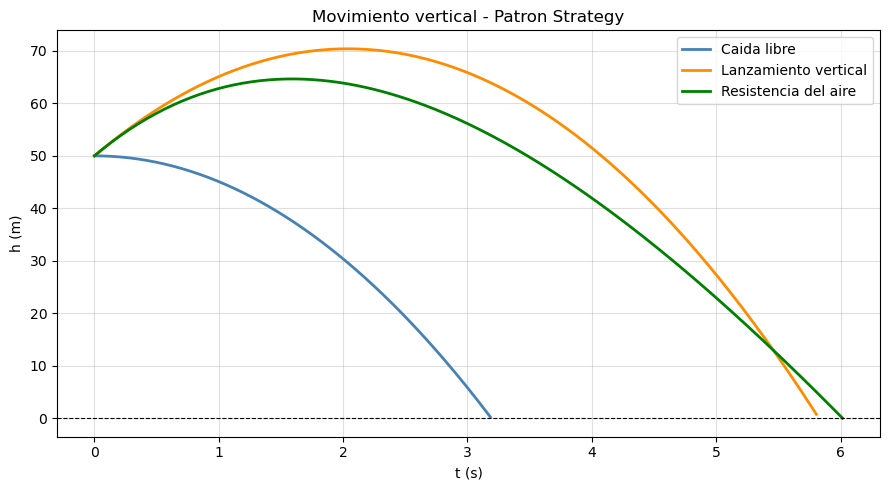

In [14]:
from abc import ABC, abstractmethod
import math, numpy as np, matplotlib.pyplot as plt

G = 9.81

class EstrategiaMovimiento(ABC):
    @abstractmethod
    def calcular_altura(self, h0, v0, masa, t): pass
    @property
    @abstractmethod
    def nombre(self): pass

class CaidaLibre(EstrategiaMovimiento):
    nombre = "Caida libre"
    def calcular_altura(self, h0, v0, masa, t):
        return h0 - 0.5*G*t**2

class LanzamientoVertical(EstrategiaMovimiento):
    nombre = "Lanzamiento vertical"
    def calcular_altura(self, h0, v0, masa, t):
        return h0 + v0*t - 0.5*G*t**2

class ConResistenciaAire(EstrategiaMovimiento):
    nombre = "Resistencia del aire"
    def __init__(self, k=0.2): self.k = k
    def calcular_altura(self, h0, v0, masa, t):
        k, m = self.k, masa
        return h0 + (m/k)*(v0+m*G/k)*(1-math.exp(-k*t/m)) - (m*G/k)*t

class ObjetoFisico:
    def __init__(self, nombre, masa, h0, v0):
        self.nombre, self.masa = nombre, masa
        self.h0, self.v0 = h0, v0
        self._estrategia = None

    def set_estrategia(self, e: EstrategiaMovimiento):
        self._estrategia = e

    def altura_en(self, t):
        return self._estrategia.calcular_altura(self.h0, self.v0, self.masa, t)


pelota = ObjetoFisico("Pelota", masa=1.0, h0=50.0, v0=20.0)

fig, ax = plt.subplots(figsize=(9, 5))
estrategias = [
    (CaidaLibre(),               "Caida libre",           "steelblue"),
    (LanzamientoVertical(),      "Lanzamiento vertical",  "darkorange"),
    (ConResistenciaAire(k=0.3), "Resistencia del aire",  "green"),
]

for est, etq, color in estrategias:
    pelota.set_estrategia(est)
    ts = np.linspace(0, 7, 300)
    hs = []
    for t in ts:
        h = pelota.altura_en(t)
        if h < 0 and hs: break
        hs.append(max(h, 0))
    ax.plot(ts[:len(hs)], hs, label=etq, color=color, lw=2)

ax.axhline(0, color="k", lw=0.8, ls="--")
ax.set_xlabel("t (s)"); ax.set_ylabel("h (m)")
ax.set_title("Movimiento vertical - Patron Strategy")
ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

### 5.4 Observer

Define una relación **uno a muchos**: cuando el sujeto cambia, todos sus observadores son notificados.

```
EstacionMeteorologica (sujeto)
    ├── PantallaActual   (observador 1)
    ├── Estadisticas     (observador 2)
    └── AlertaCalor      (observador 3)
```

In [15]:
from abc import ABC, abstractmethod
import random

class Observador(ABC):
    @abstractmethod
    def actualizar(self, sujeto): pass

class EstacionMeteorologica:
    """Sujeto: notifica a todos los observadores cuando cambian los datos."""

    def __init__(self):
        self._observadores = []
        self.temperatura = self.humedad = self.presion = 0

    def registrar(self, obs):    self._observadores.append(obs)
    def desregistrar(self, obs): self._observadores.remove(obs)

    def _notificar(self):
        for obs in self._observadores:
            obs.actualizar(self)

    def set_mediciones(self, temp, hum, pres):
        self.temperatura, self.humedad, self.presion = temp, hum, pres
        self._notificar()

class PantallaActual(Observador):
    def actualizar(self, e):
        print(f"  [Pantalla]  T={e.temperatura:.1f}C  "
              f"H={e.humedad:.0f}%  P={e.presion:.0f} hPa")

class Estadisticas(Observador):
    def __init__(self): self._temps = []
    def actualizar(self, e):
        self._temps.append(e.temperatura)
        print(f"  [Stats]     min={min(self._temps):.1f} "
              f"max={max(self._temps):.1f} "
              f"avg={sum(self._temps)/len(self._temps):.1f} C")

class AlertaCalor(Observador):
    def __init__(self, umbral=33): self.umbral = umbral
    def actualizar(self, e):
        if e.temperatura > self.umbral:
            print(f"  ALERTA: Temperatura alta: {e.temperatura:.1f}C")


estacion = EstacionMeteorologica()
estacion.registrar(PantallaActual())
estacion.registrar(Estadisticas())
estacion.registrar(AlertaCalor(umbral=33))

random.seed(42)
print("=== Simulacion de 5 lecturas ===")
for i in range(5):
    t = round(random.uniform(25, 38), 1)
    h = round(random.uniform(40, 80), 0)
    p = round(random.uniform(1005, 1015), 0)
    print(f"\nLectura {i+1}:")
    estacion.set_mediciones(t, h, p)

=== Simulacion de 5 lecturas ===

Lectura 1:
  [Pantalla]  T=33.3C  H=41%  P=1008 hPa
  [Stats]     min=33.3 max=33.3 avg=33.3 C
  ALERTA: Temperatura alta: 33.3C

Lectura 2:
  [Pantalla]  T=27.9C  H=69%  P=1012 hPa
  [Stats]     min=27.9 max=33.3 avg=30.6 C

Lectura 3:
  [Pantalla]  T=36.6C  H=43%  P=1009 hPa
  [Stats]     min=27.9 max=36.6 avg=32.6 C
  ALERTA: Temperatura alta: 36.6C

Lectura 4:
  [Pantalla]  T=25.4C  H=49%  P=1010 hPa
  [Stats]     min=25.4 max=36.6 avg=30.8 C

Lectura 5:
  [Pantalla]  T=25.3C  H=48%  P=1011 hPa
  [Stats]     min=25.3 max=36.6 avg=29.7 C


---
## 6. Módulos y paquetes

```
mi_fisica/              <- paquete
├── __init__.py         <- hace que la carpeta sea un paquete
└── vectores.py         <- modulo con clase Vector
```

In [16]:
import os
os.makedirs("mi_fisica", exist_ok=True)

In [17]:
%%writefile mi_fisica/vectores.py
"""Modulo con la clase Vector."""
import math

class Vector:
    def __init__(self, x, y, z=0):
        self.x, self.y, self.z = x, y, z
    def __add__(self, o): return Vector(self.x+o.x, self.y+o.y, self.z+o.z)
    def __abs__(self):    return math.sqrt(self.x**2+self.y**2+self.z**2)
    def __str__(self):    return f"({self.x}, {self.y}, {self.z})"

def angulo_entre(v1, v2):
    """Angulo en grados entre dos vectores."""
    cos_a = (v1.x*v2.x+v1.y*v2.y+v1.z*v2.z) / (abs(v1)*abs(v2))
    return math.degrees(math.acos(max(-1, min(1, cos_a))))

Writing mi_fisica/vectores.py


In [18]:
%%writefile mi_fisica/__init__.py
"""Paquete mi_fisica."""
from .vectores import Vector, angulo_entre

Writing mi_fisica/__init__.py


In [19]:
import importlib, sys
for mod in list(sys.modules):
    if "mi_fisica" in mod: del sys.modules[mod]

from mi_fisica import Vector, angulo_entre

v1 = Vector(1, 0, 0)
v2 = Vector(0, 1, 0)
print("v1:", v1)
print("v2:", v2)
print("v1 + v2:", v1 + v2)
print(f"Angulo v1-v2: {angulo_entre(v1, v2):.1f} grados")  # debe ser 90

v1: (1, 0, 0)
v2: (0, 1, 0)
v1 + v2: (1, 1, 0)
Angulo v1-v2: 90.0 grados


---
## 7. Buenas prácticas — Principios SOLID

| Letra | Nombre | Frase clave |
|-------|--------|-------------|
| **S** | Single Responsibility | Una clase = una razón para cambiar |
| **O** | Open/Closed | Extensión sin modificación |
| **L** | Liskov Substitution | Subclase sustituye a superclase |
| **I** | Interface Segregation | Interfaces pequeñas y focalizadas |
| **D** | Dependency Inversion | Depender de abstracciones |

### S — Responsabilidad Única

In [20]:
# MAL: una clase hace demasiado
class ReporteMAL:
    def __init__(self, datos):  self.datos = datos
    def calcular(self):         return sum(self.datos)
    def imprimir(self):         print("Total:", self.calcular())
    def guardar_csv(self, ruta): open(ruta,"w").write(str(self.calcular()))

# BIEN: una responsabilidad por clase
class Reporte:
    def __init__(self, datos): self.datos = datos
    def total(self): return sum(self.datos)

class ImpresoraReporte:
    def imprimir(self, r): print(f"Total: {r.total()}")

class ExportadorCSV:
    def guardar(self, r, ruta):
        with open(ruta, "w") as f: f.write(f"total,{r.total()}\n")
        print(f"Guardado en {ruta}")

r = Reporte([100, 200, 300])
ImpresoraReporte().imprimir(r)
ExportadorCSV().guardar(r, "/tmp/rep.csv")

Total: 600
Guardado en /tmp/rep.csv


### O — Abierto/Cerrado

In [21]:
from abc import ABC, abstractmethod

class Descuento(ABC):
    @abstractmethod
    def aplicar(self, precio): pass

class SinDescuento(Descuento):
    def aplicar(self, precio): return precio

class Descuento10(Descuento):
    def aplicar(self, precio): return precio * 0.90

class DescuentoNavidad(Descuento):   # extension SIN modificar nada anterior
    def aplicar(self, precio): return precio * 0.75

def precio_final(base, descuento: Descuento):
    return descuento.aplicar(base)

for d in [SinDescuento(), Descuento10(), DescuentoNavidad()]:
    print(f"{type(d).__name__:20s}: ${precio_final(100, d):.2f}")

SinDescuento        : $100.00
Descuento10         : $90.00
DescuentoNavidad    : $75.00


### L — Sustitución de Liskov

In [22]:
from abc import ABC, abstractmethod
import math

class Forma(ABC):
    @abstractmethod
    def area(self) -> float: pass

class Circulo(Forma):
    def __init__(self, r): self.r = r
    def area(self): return math.pi * self.r**2

class Cuadrado(Forma):
    def __init__(self, lado): self.lado = lado
    def area(self): return self.lado**2

def imprimir_area(forma: Forma):   # acepta cualquier Forma -> LSP
    print(f"{type(forma).__name__:12s}: {forma.area():.3f}")

for f in [Circulo(3), Cuadrado(4)]:
    imprimir_area(f)

Circulo     : 28.274
Cuadrado    : 16.000


### D — Inversión de Dependencias

In [23]:
from abc import ABC, abstractmethod

# MAL: acoplado a Email concreto
class NotificadorMAL:
    def notificar(self, msg): print(f"Email fijo: {msg}")

# BIEN: depende de la abstraccion Canal
class Canal(ABC):
    @abstractmethod
    def enviar(self, mensaje): pass

class Email(Canal):
    def enviar(self, m): print(f"Email: {m}")

class SMS(Canal):
    def enviar(self, m): print(f"SMS: {m}")

class Push(Canal):
    def enviar(self, m): print(f"Push: {m}")

class Notificador:
    def __init__(self, canal: Canal):  # inyeccion de dependencia
        self._canal = canal
    def notificar(self, mensaje):
        self._canal.enviar(mensaje)

for canal in [Email(), SMS(), Push()]:
    Notificador(canal).notificar("Tu pedido esta listo")

Email: Tu pedido esta listo
SMS: Tu pedido esta listo
Push: Tu pedido esta listo


---
## 8. Aplicación completa — Simulación física

Integramos: clases, herencia, abstracción, polimorfismo, Strategy y matplotlib.

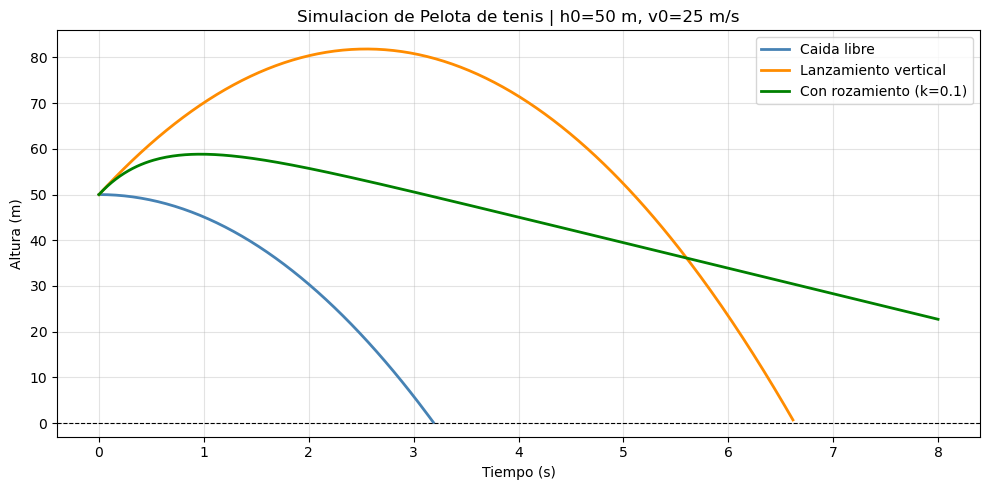

In [24]:
from abc import ABC, abstractmethod
import math, numpy as np, matplotlib.pyplot as plt

G = 9.81

class Movimiento(ABC):
    @abstractmethod
    def altura(self, h0, v0, masa, t): pass

class CaidaLibre(Movimiento):
    def altura(self, h0, v0, masa, t): return h0 - 0.5*G*t**2

class LanzamientoVertical(Movimiento):
    def altura(self, h0, v0, masa, t): return h0 + v0*t - 0.5*G*t**2

class ConRozamiento(Movimiento):
    def __init__(self, k=0.2): self.k = k
    def altura(self, h0, v0, masa, t):
        k, m = self.k, masa
        return h0 + (m/k)*(v0+m*G/k)*(1-math.exp(-k*t/m)) - (m*G/k)*t

class CuerpoLanzado:
    """Delega su movimiento a una estrategia."""

    def __init__(self, nombre, masa, h0, v0):
        self.nombre = nombre
        self.masa, self.h0, self.v0 = masa, h0, v0

    def simular(self, movimiento: Movimiento, t_max=8, n=400):
        ts = np.linspace(0, t_max, n)
        hs, tiempos = [], []
        for t in ts:
            h = movimiento.altura(self.h0, self.v0, self.masa, t)
            if h < 0 and tiempos: break
            tiempos.append(t)
            hs.append(max(h, 0))
        return np.array(tiempos), np.array(hs)

    def graficar(self, movimientos, etiquetas, colores=None):
        colores = colores or ["steelblue","darkorange","green"]
        fig, ax = plt.subplots(figsize=(10, 5))
        for i, (mov, etq) in enumerate(zip(movimientos, etiquetas)):
            ts, hs = self.simular(mov)
            ax.plot(ts, hs, label=etq, color=colores[i%len(colores)], lw=2)
        ax.axhline(0, color="k", lw=0.8, ls="--")
        ax.set_ylim(bottom=-3)
        ax.set_xlabel("Tiempo (s)"); ax.set_ylabel("Altura (m)")
        ax.set_title(f"Simulacion de {self.nombre} | h0={self.h0} m, v0={self.v0} m/s")
        ax.legend(); ax.grid(True, alpha=0.35)
        plt.tight_layout(); plt.show()


pelota = CuerpoLanzado("Pelota de tenis", masa=0.057, h0=50, v0=25)
pelota.graficar(
    movimientos=[CaidaLibre(), LanzamientoVertical(), ConRozamiento(k=0.1)],
    etiquetas=["Caida libre", "Lanzamiento vertical", "Con rozamiento (k=0.1)"]
)

---
## 9. Resumen

```
Clase
  __init__         -> inicializa atributos
  Metodos normales -> comportamiento
  Metodos dunder   -> integracion con Python (+, print, len...)

Encapsulamiento
  atributo         -> publico
  _atributo        -> protegido (convencion)
  __atributo       -> privado (name mangling)
  @property        -> getter/setter elegante

Herencia
  class Hija(Madre) -> hereda todo
  super().__init__ -> llama al constructor padre
  isinstance()     -> verifica jerarquia

Abstraccion
  ABC + @abstractmethod -> metodo obligatorio en subclases
  No se puede instanciar la clase abstracta directamente

Patrones
  Singleton   -> __new__, _instancia compartida
  Factory     -> delega creacion a subclases
  Strategy    -> algoritmos intercambiables
  Observer    -> notificacion automatica

SOLID
  S -> una clase, una razon para cambiar
  O -> extension sin modificacion
  L -> subclase sustituye a superclase
  I -> interfaces pequenas y focalizadas
  D -> depender de abstracciones
```

## Referencias

1. Lutz, M. *Learning Python*, O'Reilly, 2013.
2. Ramalho, L. *Fluent Python*, O'Reilly, 2022.
3. Martin, R. C. *Clean Code*, Prentice Hall, 2008.
4. Gamma et al. *Design Patterns*, Addison-Wesley, 1994.
5. Documentacion Python — `abc`: https://docs.python.org/3/library/abc.html
6. Metodos especiales: https://www.pythonmorsels.com/every-dunder-method/